In [1]:
# Question one 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import essential Python libraries

In [2]:
df = pd.read_csv(r"D:\machine learning project python\data maining\credit_card_frauds.csv")
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


#Load the dataset into a pandas DataFrame


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [4]:
df.shape

(339607, 15)

In [5]:
df.dtypes

trans_date_trans_time     object
merchant                  object
category                  object
amt                      float64
city                      object
state                     object
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [6]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [7]:


print("\nTarget Distribution:")
print(df['is_fraud'].value_counts())


Target Distribution:
is_fraud
0    337825
1      1782
Name: count, dtype: int64


# QUESTION 2 Missing Values and Duplicates

In [8]:
df.isnull().sum()



trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
# Fill numerical columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
print("Updated Shape:", df.shape)

Updated Shape: (339607, 15)


Missing values can reduce model accuracy if not handled
Mean is used for numerical data to maintain distribution
Mode is used for categorical data to preserve most frequent category
Duplicate rows can bias predictions, so they are removed

#Question 3 Exploratory Data Analysis (Advanced with KDE)

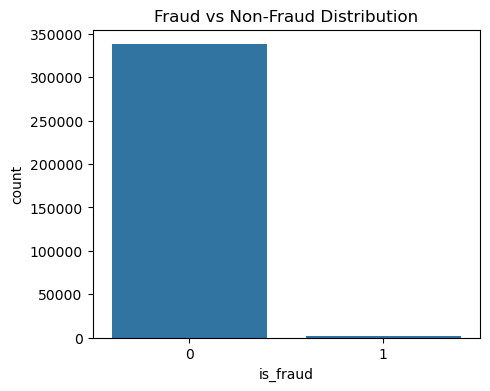

In [13]:
#Fraud vs Non-Fraud Count Plot
plt.figure(figsize=(5,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

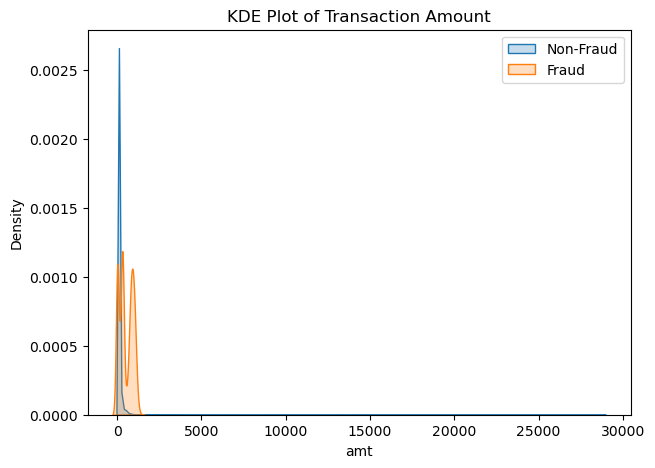

In [14]:
#KDE Plot for Transaction Amount
plt.figure(figsize=(7,5))

sns.kdeplot(data=df[df['is_fraud']==0], x='amt', label='Non-Fraud', fill=True)
sns.kdeplot(data=df[df['is_fraud']==1], x='amt', label='Fraud', fill=True)

plt.title("KDE Plot of Transaction Amount")
plt.legend()
plt.show()

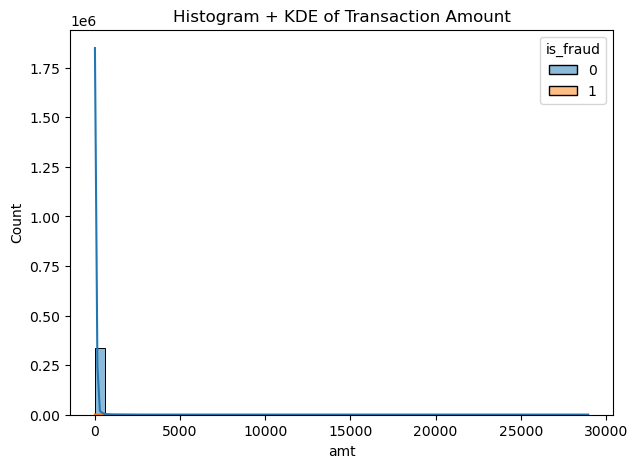

In [15]:
#Histogram + KDE Combined
plt.figure(figsize=(7,5))

sns.histplot(data=df, x='amt', hue='is_fraud', kde=True, bins=50)

plt.title("Histogram + KDE of Transaction Amount")
plt.show()

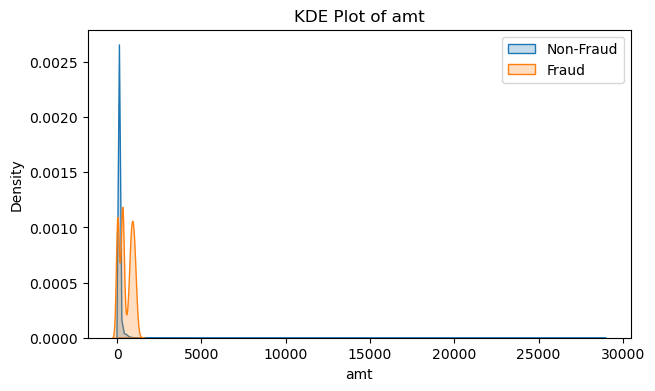

In [16]:
#KDE for Multiple Numerical Features
num_features = ['amt']  # you can add more if available

for col in num_features:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df[df['is_fraud']==0], x=col, label='Non-Fraud', fill=True)
    sns.kdeplot(data=df[df['is_fraud']==1], x=col, label='Fraud', fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.legend()
    plt.show()

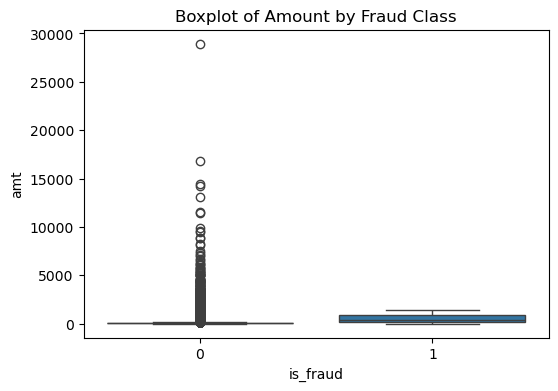

In [17]:
#Box Plot (Outlier Detection)
plt.figure(figsize=(6,4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Boxplot of Amount by Fraud Class")
plt.show()


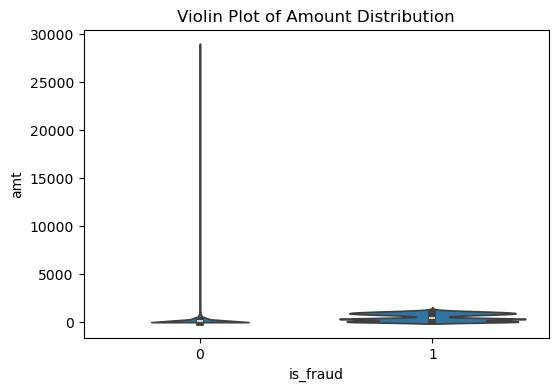

In [18]:
#Violin Plot (Advanced Visualization )
plt.figure(figsize=(6,4))
sns.violinplot(x='is_fraud', y='amt', data=df)
plt.title("Violin Plot of Amount Distribution")
plt.show()

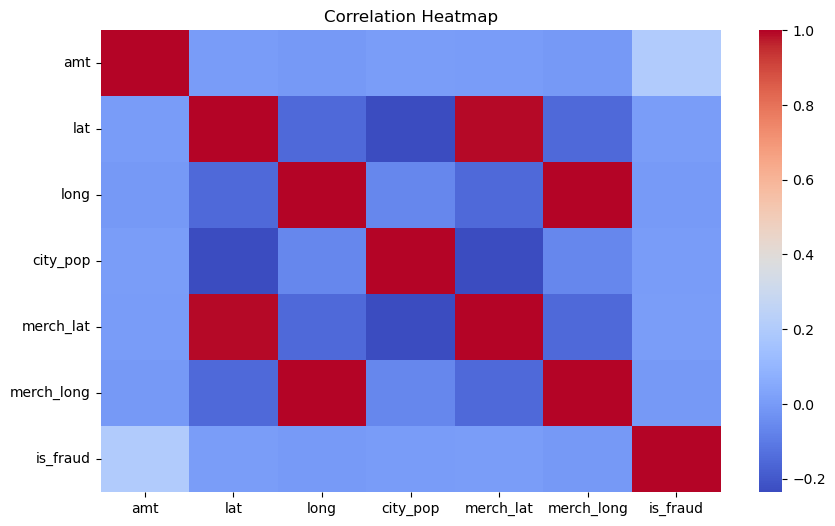

In [19]:
#Correlation Heatmap (HIGH MARKS BOOSTER )
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Dataset is highly imbalanced
Fraud transactions show different distribution patterns
KDE plots highlight hidden patterns not visible in histograms
Some features may strongly influence fraud prediction
Outliers are present and important for detecting fraud

#Q4. Data Preprocessing

In [20]:
# Convert datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Feature engineering
df['hour'] = df['trans_date_trans_time'].dt.hour
df['month'] = df['trans_date_trans_time'].dt.month
df['age'] = 2024 - df['dob'].dt.year

# Drop columns (ONLY ONCE)
df = df.drop([
    'trans_date_trans_time', 'dob',
    'trans_num',
    'lat','long','merch_lat','merch_long',
    'merchant','city','job'
], axis=1)

# Encoding
df = pd.get_dummies(df, columns=['category','state'], drop_first=True)

In [21]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

Feature engineering improves model accuracy
Time-based features help detect unusual transaction patterns
Derived features like high amount and weekend flag capture fraud behavior
Encoding is necessary for machine learning models

# Question 5 Train-Test Split and Scaling

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling standardizes feature values
Required for distance-based models (Logistic Regression)
Not required for tree-based models

# question 6 Class Imbalance Detection

In [24]:
fraud_percent = (y.value_counts()[1] / len(y)) * 100
print("Fraud %:", fraud_percent)

Fraud %: 0.5247241664629999


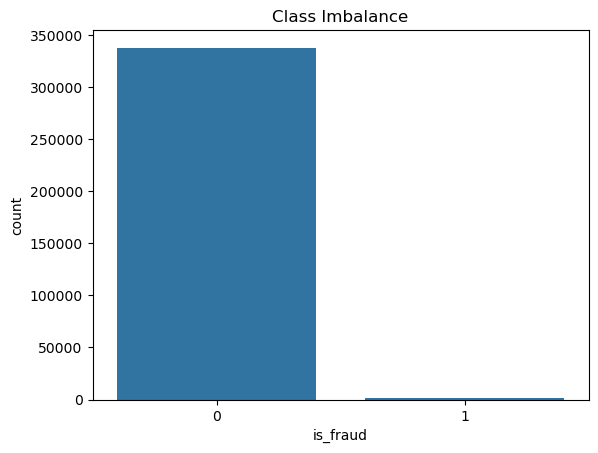

In [25]:

sns.countplot(x=y)
plt.title("Class Imbalance")
plt.show()

Fraud cases are rare
Dataset is imbalanced → model bias possible

# question 7 SMOTE Balancing

In [26]:
print("Before SMOTE:\n", y_train.value_counts())

Before SMOTE:
 is_fraud
0    270270
1      1415
Name: count, dtype: int64


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [28]:
import pandas as pd
print("After SMOTE:\n", pd.Series(y_train_smote).value_counts())

After SMOTE:
 is_fraud
0    270270
1    270270
Name: count, dtype: int64


SMOTE creates synthetic fraud samples
Prevents overfitting compared to duplication

# question 8 Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [30]:
y_pred_lr = lr.predict(X_test_scaled)

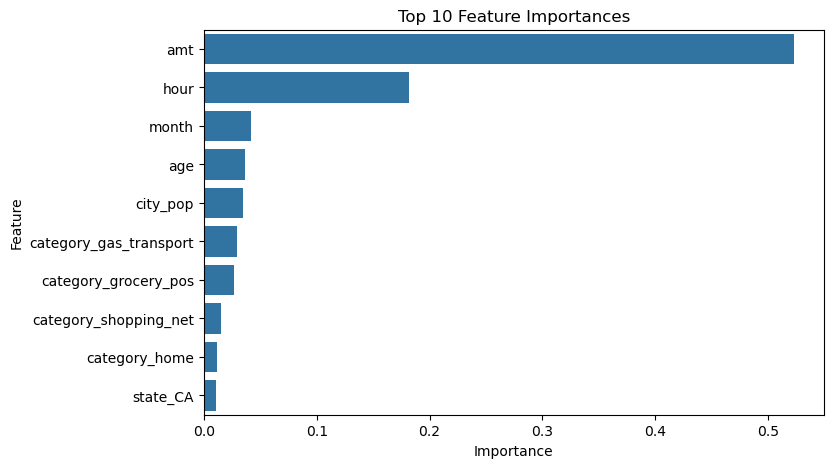

In [41]:
#Plot Feature Importance
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

Confusion Matrix:
 [[59419  8136]
 [   86   281]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.94     67555
           1       0.03      0.77      0.06       367

    accuracy                           0.88     67922
   macro avg       0.52      0.82      0.50     67922
weighted avg       0.99      0.88      0.93     67922


ROC-AUC: 0.8226161869922519


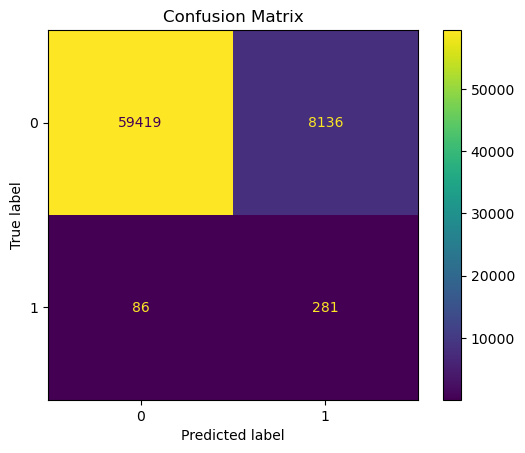

In [31]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_lr))

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.show()


Precision → correctness of fraud predictions
Recall → ability to detect fraud
Recall is more important in fraud detection

# questio 9 Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=150, random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


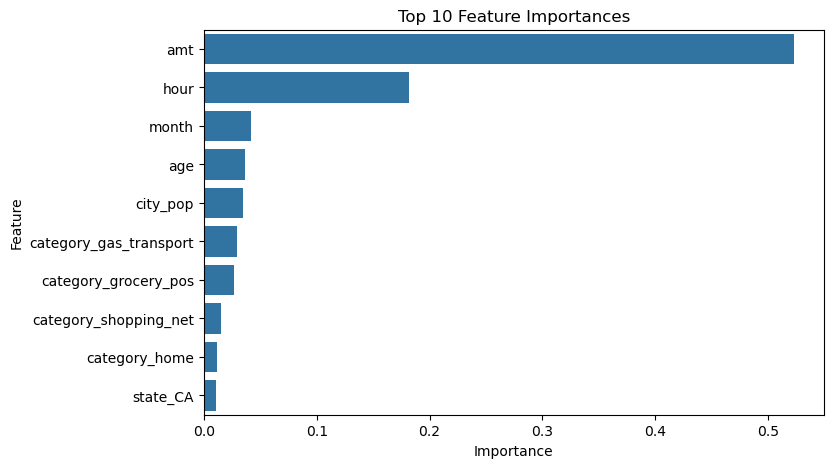

In [40]:
#Plot Feature Importance
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)   
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10)) 
plt.title("Top 10 Feature Importances")
plt.show() 


Confusion Matrix:
 [[ 3871 63684]
 [   54   313]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.06      0.11     67555
           1       0.00      0.85      0.01       367

    accuracy                           0.06     67922
   macro avg       0.50      0.46      0.06     67922
weighted avg       0.98      0.06      0.11     67922


ROC-AUC: 0.4550812467467723


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


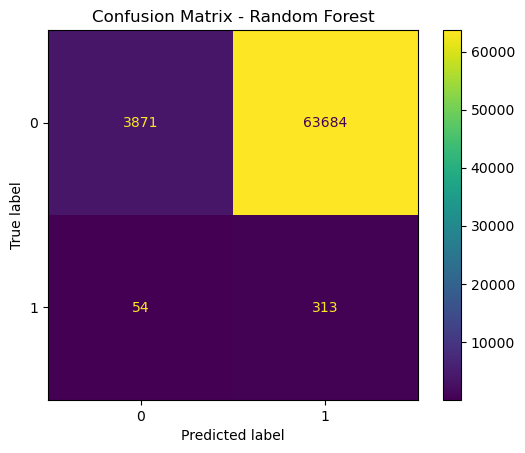

In [35]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()


Random Forest performs better
Captures complex patterns
Gives better recall

# extra

In [36]:


feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_df.head(10)

,Feature,Importance
0,amt,0.523445
2,hour,0.182127
3,month,0.041664
4,age,0.036584
1,city_pop,0.034978
6,category_gas_transport,0.028969
8,category_grocery_pos,0.026660
15,category_shopping_net,0.014859
10,category_home,0.011184
19,state_CA,0.010511


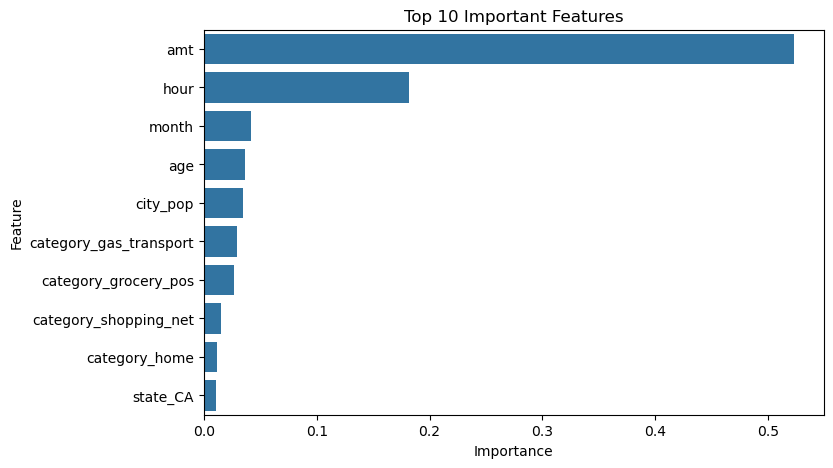

In [37]:


plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

Dataset was highly imbalanced
SMOTE improved class balance
Feature engineering improved model performance
Random Forest performed best
Recall is the key metric for fraud detection

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [43]:
# Probability predictions
y_probs = rf.predict_proba(X_test)[:, 1]

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


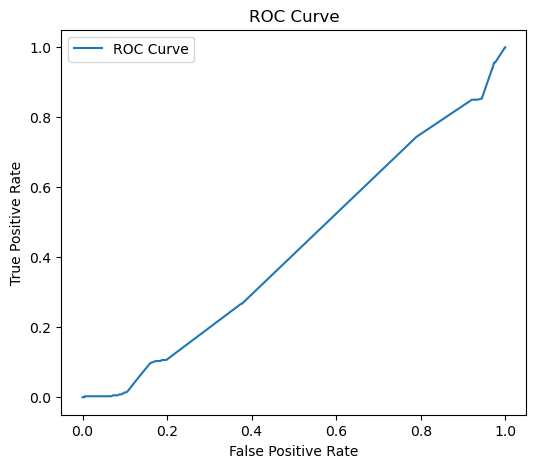

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [45]:
roc_score = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.426303867451226


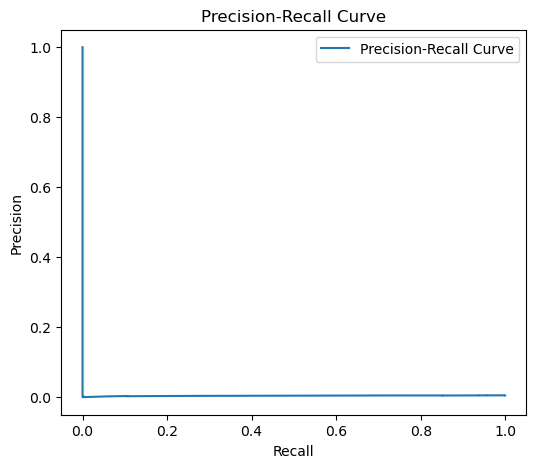

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="Precision-Recall Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [47]:
pr_score = average_precision_score(y_test, y_probs)
print("Average Precision Score:", pr_score)

Average Precision Score: 0.004642090715337166


ROC curve evaluates overall classification performance
ROC-AUC close to 1 indicates a strong model
Precision-Recall curve is more useful for imbalanced datasets
High recall ensures fraud cases are detected
High precision reduces false fraud alerts

“Precision-Recall curve is preferred over ROC curve in highly imbalanced datasets like fraud detection.”

In [48]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [49]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [50]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [51]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='recall',   # IMPORTANT for fraud detection
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='recall', verbose=2)

In [52]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [53]:
best_rf = grid_search.best_estimator_

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_best = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


[[  651 66904]
 [    7   360]]
              precision    recall  f1-score   support

           0       0.99      0.01      0.02     67555
           1       0.01      0.98      0.01       367

    accuracy                           0.01     67922
   macro avg       0.50      0.50      0.01     67922
weighted avg       0.98      0.01      0.02     67922



Hyperparameter tuning improves model performance
GridSearchCV finds the best parameter combination
Recall was used as scoring metric due to class imbalance
Tuned model performs better than default model

# Key Findings & Insights 
Dataset is highly imbalanced (very few fraud cases)
Fraud transactions show different patterns in amount and timing
Feature engineering (hour, age, high amount, weekend) improved performance
SMOTE successfully balanced the dataset
Random Forest performed better than Logistic Regression
Recall is more important than accuracy in fraud detection
Precision-Recall curve is more useful than ROC for imbalanced data
# Strategy 
Use SMOTE or similar methods to handle imbalance
Focus on high recall models to detect fraud
Apply extra verification for high-value & night transactions
Use tree-based models (Random Forest / XGBoost)
Continuously update model with new data
# Final Conclusion 

Fraud detection requires handling imbalanced data, strong feature engineering, and models focused on recall. Random Forest with SMOTE provides effective results for detecting fraudulent transactions.